In [1]:
%load_ext autoreload
%autoreload 2

# Model differencing

`lensboy` has tools to compare two different camera intrinsics.

This can be useful to, for example
* Cross-validate your calibration
* Check whether your camera calibrtion has changed
* Compare two cameras of the same type to see how much the intrinsics differ

In this notebook, we'll explore how to do this with `lensboy`.


In [2]:
from pathlib import Path
import imageio.v3 as iio
import mediapy
import cv2

import lensboy as lb
import lensboy.analysis as lba

## Load dataset

""

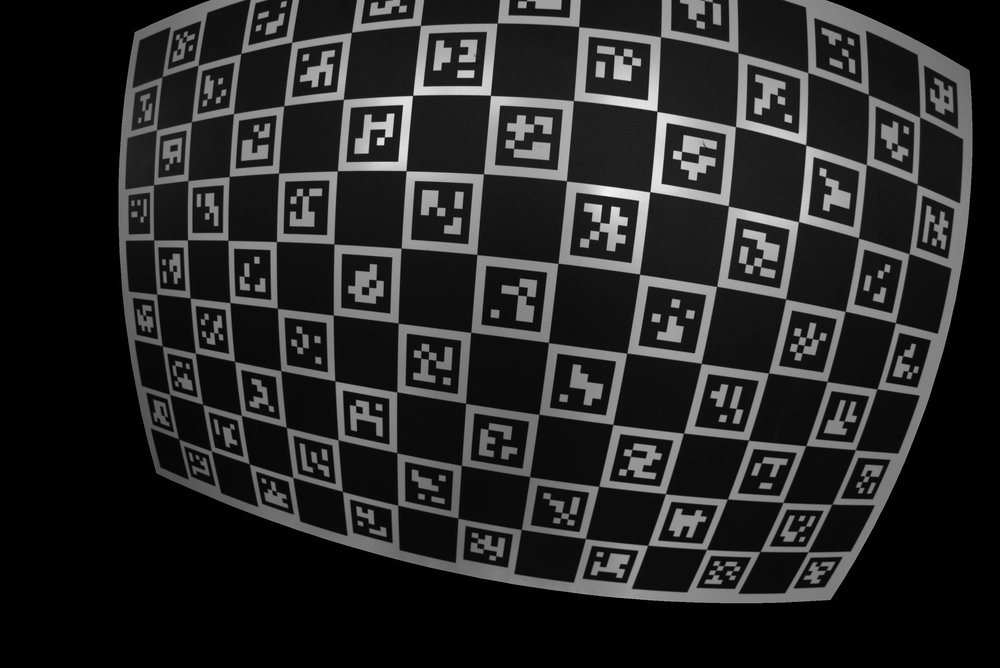

In [3]:
img_directory = Path("../data/images/wide_angle_charuco_private")
img_paths = sorted(img_directory.glob("*.png"))
imgs = [iio.imread(pth) for pth in img_paths]

# if you're running the notebook yourself, you can use this for synthetic images
# from lensboy.demo import make_synthetic_images
# imgs = make_synthetic_images()

mediapy.show_image(imgs[0], width=1000)

Extract charuco detections from the images.

In [4]:
board = cv2.aruco.CharucoBoard(
    (14, 9), 40, 30, cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_5X5_100)
)
target_points, frames, image_indices = lb.extract_frames_from_charuco(board, imgs)
used_imgs = [imgs[i] for i in image_indices]

image_height, image_width = used_imgs[0].shape[:2]

Detecting charuco: 101/101 (100.0%)
Detected charuco in 101/101 images


We'll split the dataset in two

In [5]:
frames_a = frames[0::2]
frames_b = frames[1::2]

print(f"{len(frames_a)=}, {len(frames_b)=}")


len(frames_a)=51, len(frames_b)=50


Let's make sure each set has decent coverage:

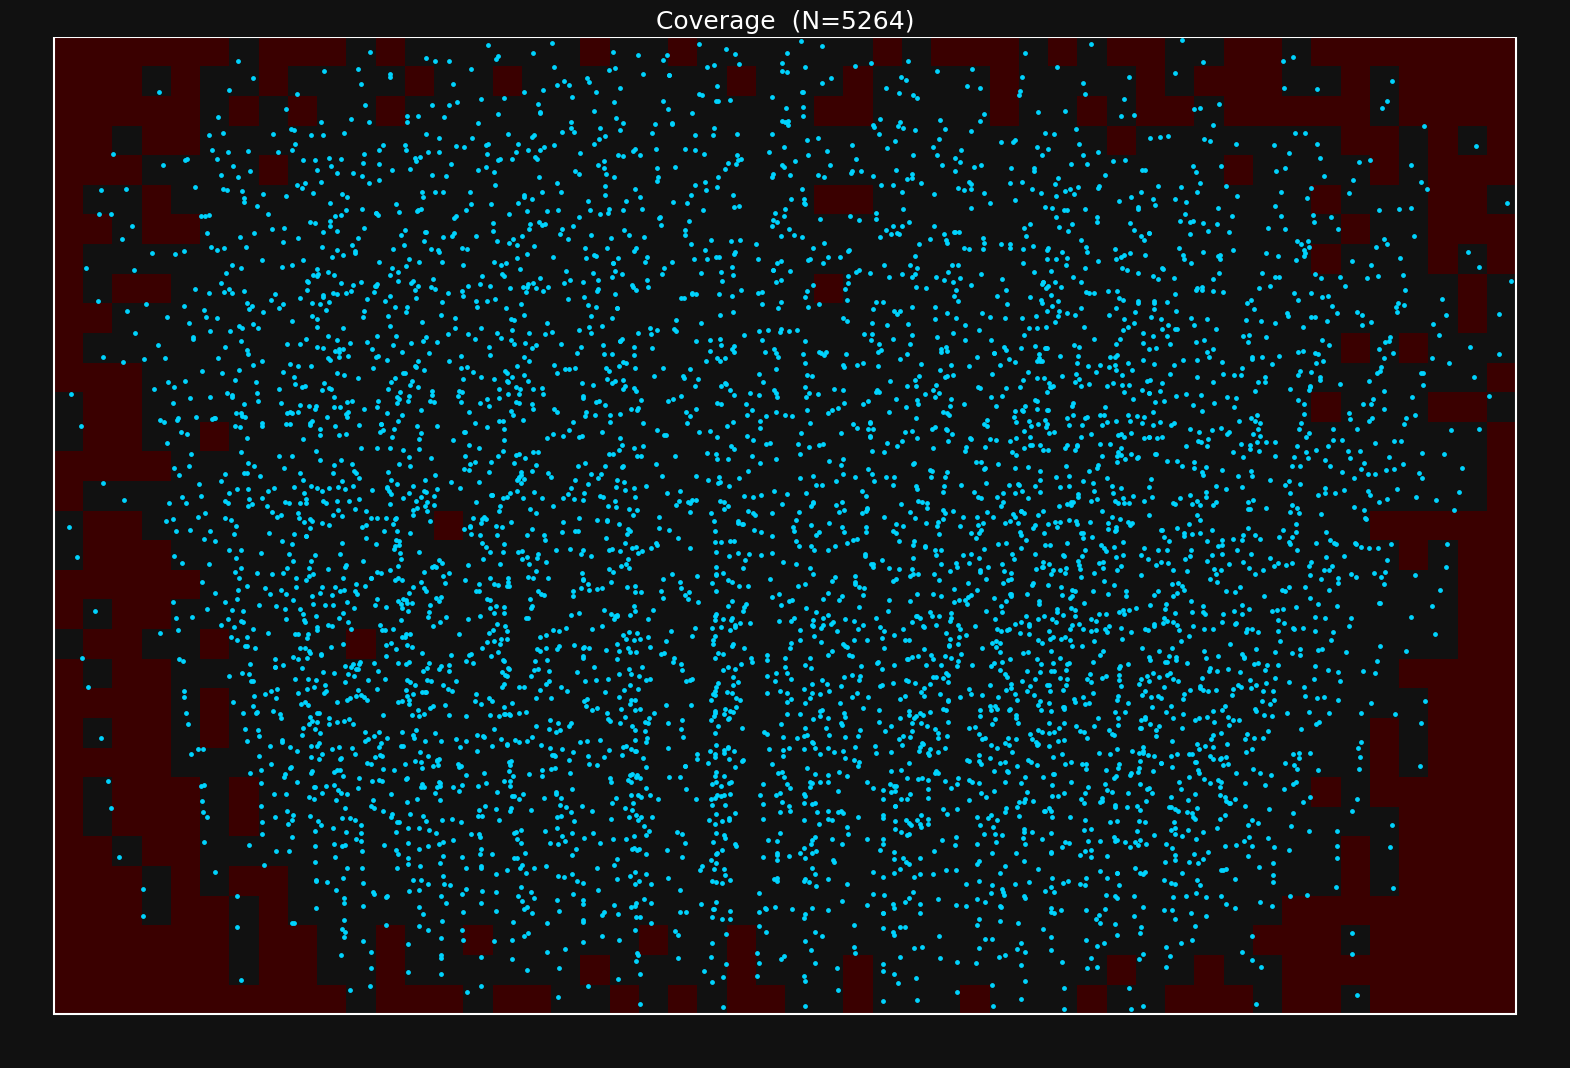

In [6]:
lba.plot_detection_coverage(
    frames_a, 
    image_width=image_width, 
    image_height=image_height
)

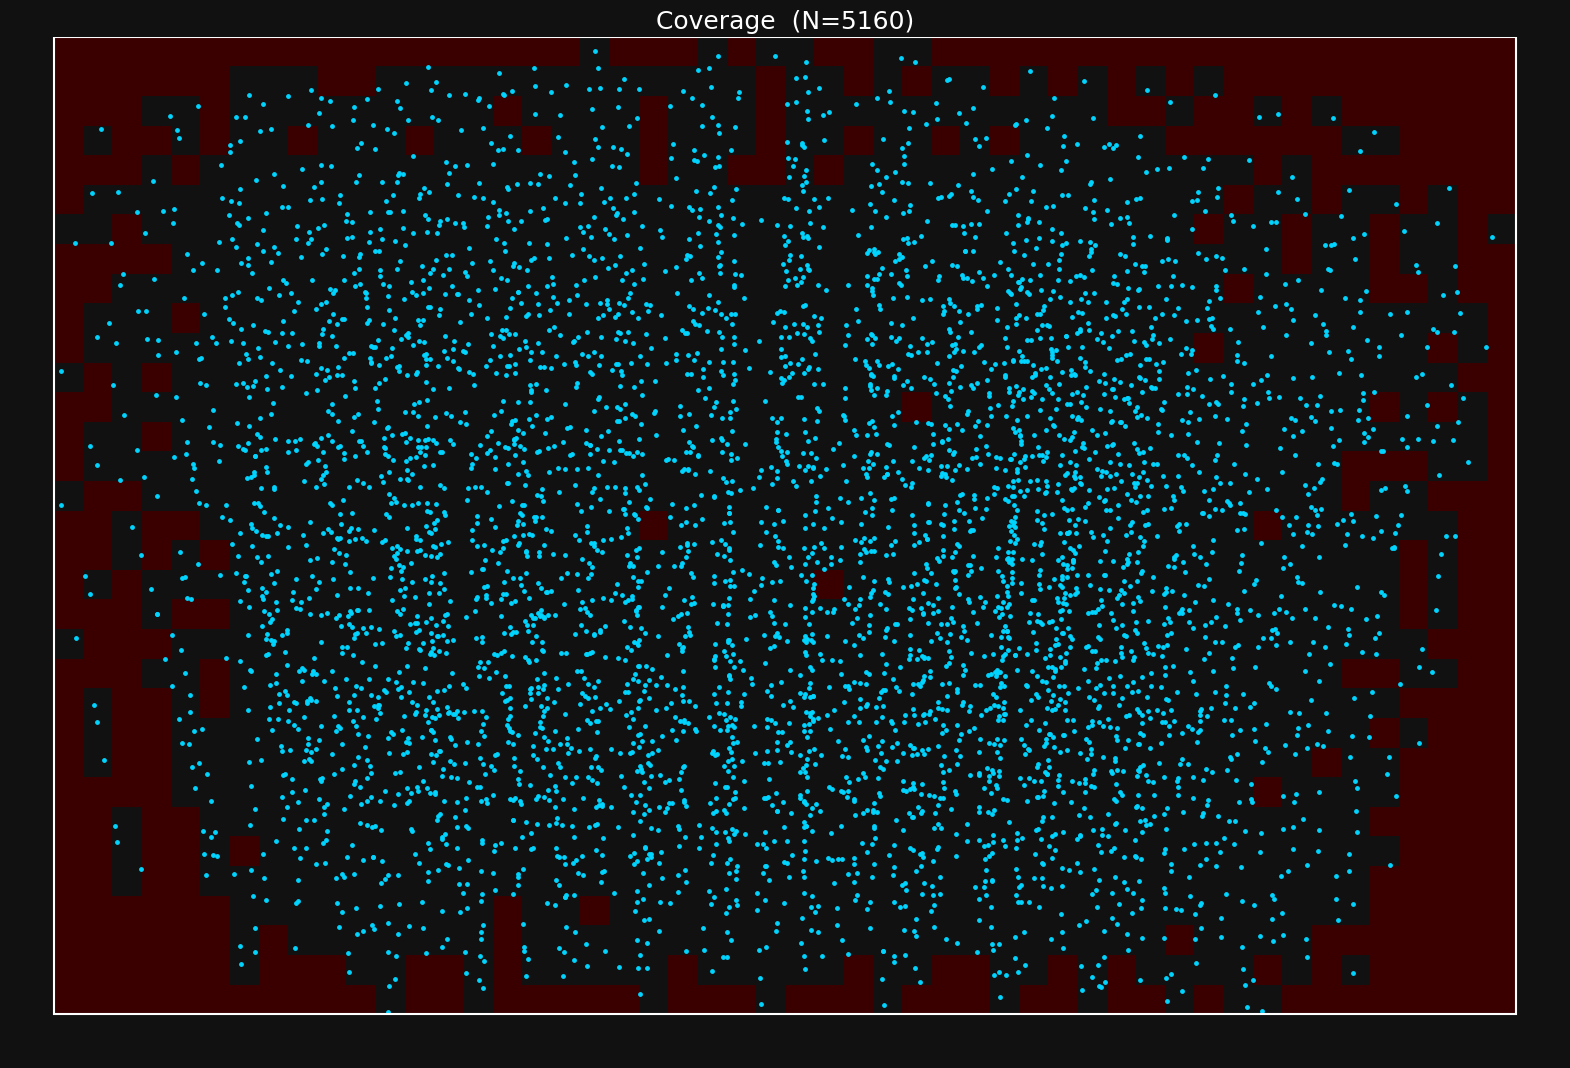

In [7]:
lba.plot_detection_coverage(
    frames_b, 
    image_width=image_width, 
    image_height=image_height
)

Looks like we have decent coverage on both sets, so we can reasonably expect to get good models from each frame set.

Let's fit an opencv model on each frame set:

In [8]:

config = lb.OpenCVConfig(
    image_height=image_height,
    image_width=image_width,
    included_distortion_coefficients=lb.OpenCVConfig.FULL_14,
)

result_a = lb.calibrate_camera(
    target_points, 
    frames_a, 
    camera_model_config=config
)

result_b = lb.calibrate_camera(
    target_points, 
    frames_b, 
    camera_model_config=config
)

opencv_model_a = result_a.camera_model
opencv_model_b = result_b.camera_model

print(f"Model A sigma: {result_a.residual_sigma_map():.3f} px")
print(f"Model B sigma: {result_b.residual_sigma_map():.3f} px")

Computing initial poses with PnP...
Auto-estimated initial focal length: 1500.9 px
PnP solved 51/51 frames
OpenCV pass 1: 0.3s (mean reproj=0.155px, worst=4.967px)
Outlier filtering: 39/5264 (0.7%) — re-optimizing...
OpenCV pass 2: 0.1s (mean reproj=0.142px, worst=0.613px)
Outlier filtering: 49/5264 (0.9%) — re-optimizing...
OpenCV pass 3: 0.1s (mean reproj=0.141px, worst=0.607px)
Target warp max deflection: 0.4622 (target units)
Computing initial poses with PnP...
Auto-estimated initial focal length: 1677.1 px
PnP solved 50/50 frames
OpenCV pass 1: 0.3s (mean reproj=0.147px, worst=3.423px)
Outlier filtering: 44/5160 (0.9%) — re-optimizing...
OpenCV pass 2: 0.2s (mean reproj=0.136px, worst=0.609px)
Outlier filtering: 56/5160 (1.1%) — re-optimizing...
OpenCV pass 3: 0.1s (mean reproj=0.135px, worst=0.524px)
Target warp max deflection: 0.4753 (target units)
Model A sigma: 0.107 px
Model B sigma: 0.100 px


Now we're ready to compare the models.

Camera intrinsics have an implied reference frame inside the physical camera. The plot tries to fit this transformation in an optimization problem, and uses it when comparing the intrinsics. See this [mrcal documentation](https://mrcal.secretsauce.net/differencing.html) for more details.

The plot shows how the same points project into each camera, with the cameras stationed relative to each other according to the fitted pose difference:

Implied rotation: x=-0.0019 y=-0.0193 z=-0.0004 deg
Implied translation: [-3.34744420e-07  3.49376461e-08  1.74688230e-08]


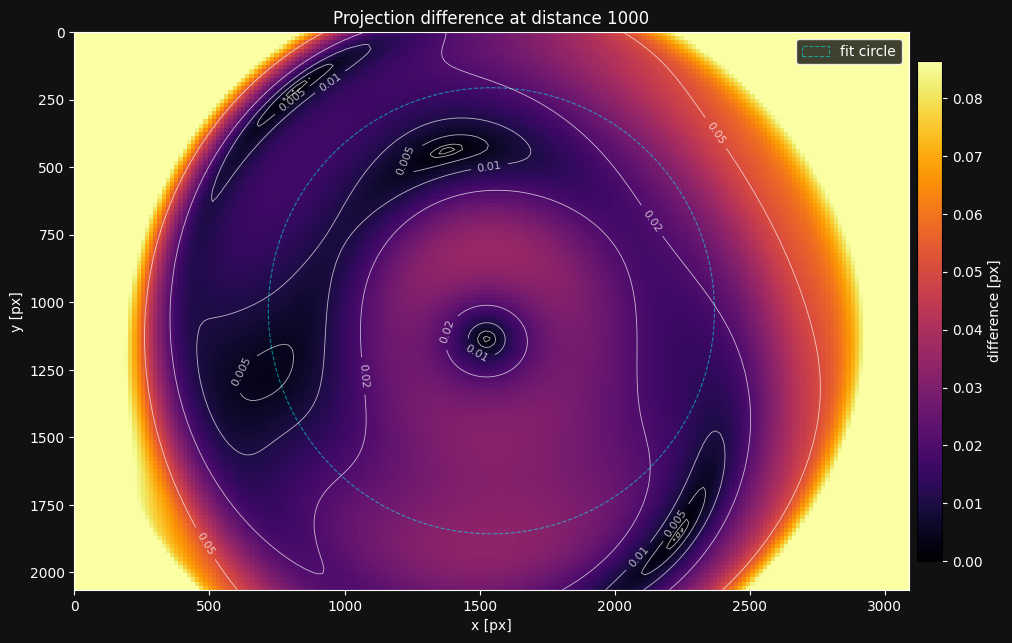

In [9]:
lba.plot_projection_diff(opencv_model_a, opencv_model_b, distance=1000)

Looks like our models align pretty well - we can say that our calibrations are pretty consistent when using the opencv model.
A possible reason is that the opencv models are so lean, they do not have the flexibility to make two models over/underfit in different ways on similar data.

## Spline models
Let's try the same with spline models. We'll look at increasing grid densities in a loop:

Fitted OpenCV seed model: 0.5s (FOV: 139.8° x 122.3°)
Spline FOV estimate: 0.4s (144.0° x 128.4°)
PnP solved 51/51 frames
Spline pass 1: 0.5s (mean reproj=0.173px, worst=4.915px)
Outlier filtering: 64/5264 (1.2%) — re-optimizing...
Spline pass 2: 0.6s (mean reproj=0.155px, worst=0.727px)
Outlier filtering: 74/5264 (1.4%) — re-optimizing...
Spline pass 3: 0.3s (mean reproj=0.153px, worst=0.603px)
Target warp max deflection: 0.4718 (target units)
Fitted OpenCV seed model: 0.5s (FOV: 139.8° x 122.3°)
Spline FOV estimate: 0.4s (143.0° x 126.4°)
PnP solved 50/50 frames
Spline pass 1: 0.7s (mean reproj=0.155px, worst=3.355px)
Outlier filtering: 67/5160 (1.3%) — re-optimizing...
Spline pass 2: 0.5s (mean reproj=0.141px, worst=0.875px)
Outlier filtering: 76/5160 (1.5%) — re-optimizing...
Spline pass 3: 0.3s (mean reproj=0.140px, worst=0.606px)
Target warp max deflection: 0.4870 (target units)
Result for 15 x 10 grid
Model A sigma: 0.115 px
Model B sigma: 0.105 px
Implied rotation: x=-0.0395 y=

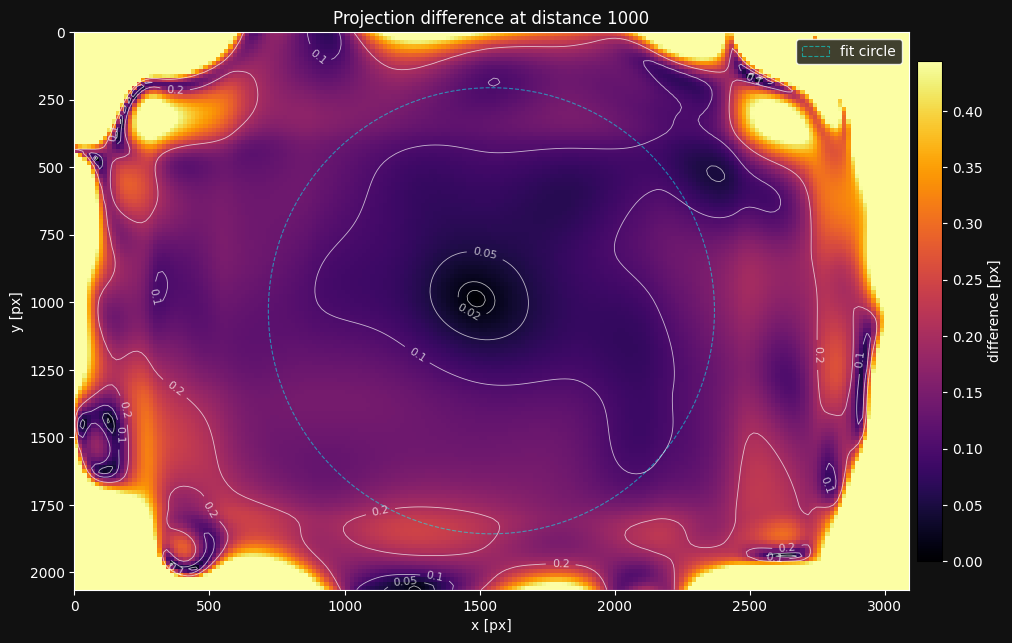

Fitted OpenCV seed model: 0.5s (FOV: 139.8° x 122.3°)
Spline FOV estimate: 0.4s (144.0° x 128.4°)
PnP solved 51/51 frames
Spline pass 1: 0.9s (mean reproj=0.137px, worst=4.955px)
Outlier filtering: 59/5264 (1.1%) — re-optimizing...
Spline pass 2: 0.4s (mean reproj=0.121px, worst=0.583px)
Outlier filtering: 74/5264 (1.4%) — re-optimizing...
Spline pass 3: 0.4s (mean reproj=0.119px, worst=0.486px)
Target warp max deflection: 0.4708 (target units)
Fitted OpenCV seed model: 0.5s (FOV: 139.8° x 122.3°)
Spline FOV estimate: 0.4s (143.0° x 126.4°)
PnP solved 50/50 frames
Spline pass 1: 0.7s (mean reproj=0.126px, worst=3.398px)
Outlier filtering: 55/5160 (1.1%) — re-optimizing...
Spline pass 2: 0.5s (mean reproj=0.115px, worst=0.529px)
Outlier filtering: 74/5160 (1.4%) — re-optimizing...
Spline pass 3: 0.6s (mean reproj=0.113px, worst=0.478px)
Target warp max deflection: 0.4802 (target units)
Result for 20 x 13 grid
Model A sigma: 0.088 px
Model B sigma: 0.081 px
Implied rotation: x=-0.0388 y=

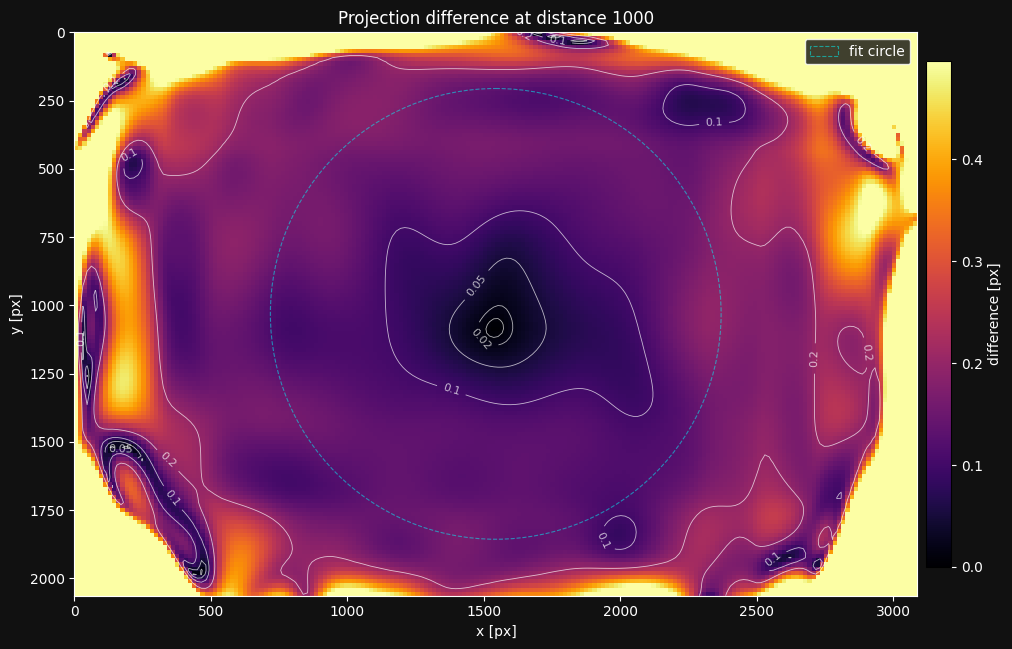

Fitted OpenCV seed model: 0.5s (FOV: 139.8° x 122.3°)
Spline FOV estimate: 0.4s (144.0° x 128.4°)
PnP solved 51/51 frames
Spline pass 1: 1.1s (mean reproj=0.132px, worst=4.936px)
Outlier filtering: 53/5264 (1.0%) — re-optimizing...
Spline pass 2: 0.7s (mean reproj=0.115px, worst=0.593px)
Outlier filtering: 70/5264 (1.3%) — re-optimizing...
Spline pass 3: 0.6s (mean reproj=0.113px, worst=0.513px)
Target warp max deflection: 0.4686 (target units)
Fitted OpenCV seed model: 0.5s (FOV: 139.8° x 122.3°)
Spline FOV estimate: 0.4s (143.0° x 126.4°)
PnP solved 50/50 frames
Spline pass 1: 0.9s (mean reproj=0.120px, worst=3.319px)
Outlier filtering: 59/5160 (1.1%) — re-optimizing...
Spline pass 2: 0.6s (mean reproj=0.107px, worst=0.594px)
Outlier filtering: 80/5160 (1.6%) — re-optimizing...
Spline pass 3: 0.6s (mean reproj=0.105px, worst=0.475px)
Target warp max deflection: 0.4825 (target units)
Result for 30 x 20 grid
Model A sigma: 0.082 px
Model B sigma: 0.076 px
Implied rotation: x=-0.0403 y=

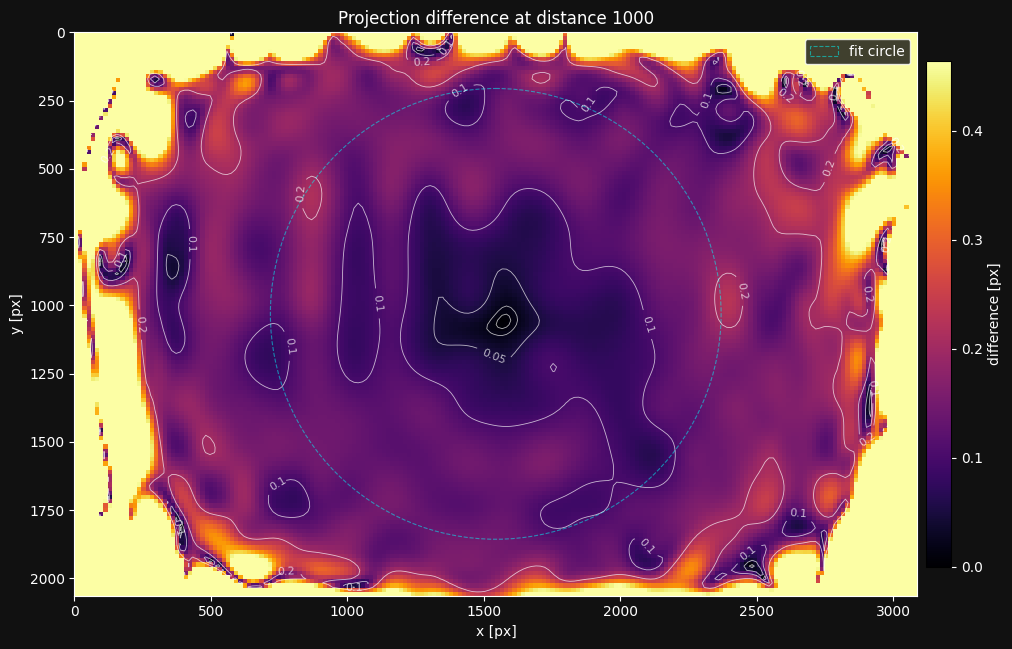

Fitted OpenCV seed model: 0.5s (FOV: 139.8° x 122.3°)
Spline FOV estimate: 0.4s (144.0° x 128.4°)
PnP solved 51/51 frames
Spline pass 1: 1.5s (mean reproj=0.129px, worst=4.841px)
Outlier filtering: 59/5264 (1.1%) — re-optimizing...
Spline pass 2: 1.1s (mean reproj=0.111px, worst=0.535px)
Outlier filtering: 78/5264 (1.5%) — re-optimizing...
Spline pass 3: 1.0s (mean reproj=0.108px, worst=0.513px)
Target warp max deflection: 0.4693 (target units)
Fitted OpenCV seed model: 0.5s (FOV: 139.8° x 122.3°)
Spline FOV estimate: 0.4s (143.0° x 126.4°)
PnP solved 50/50 frames
Spline pass 1: 1.5s (mean reproj=0.115px, worst=3.189px)
Outlier filtering: 52/5160 (1.0%) — re-optimizing...
Spline pass 2: 1.1s (mean reproj=0.103px, worst=0.444px)
Outlier filtering: 65/5160 (1.3%) — re-optimizing...
Spline pass 3: 1.0s (mean reproj=0.102px, worst=0.475px)
Target warp max deflection: 0.4869 (target units)
Result for 40 x 26 grid
Model A sigma: 0.080 px
Model B sigma: 0.073 px
Implied rotation: x=-0.0383 y=

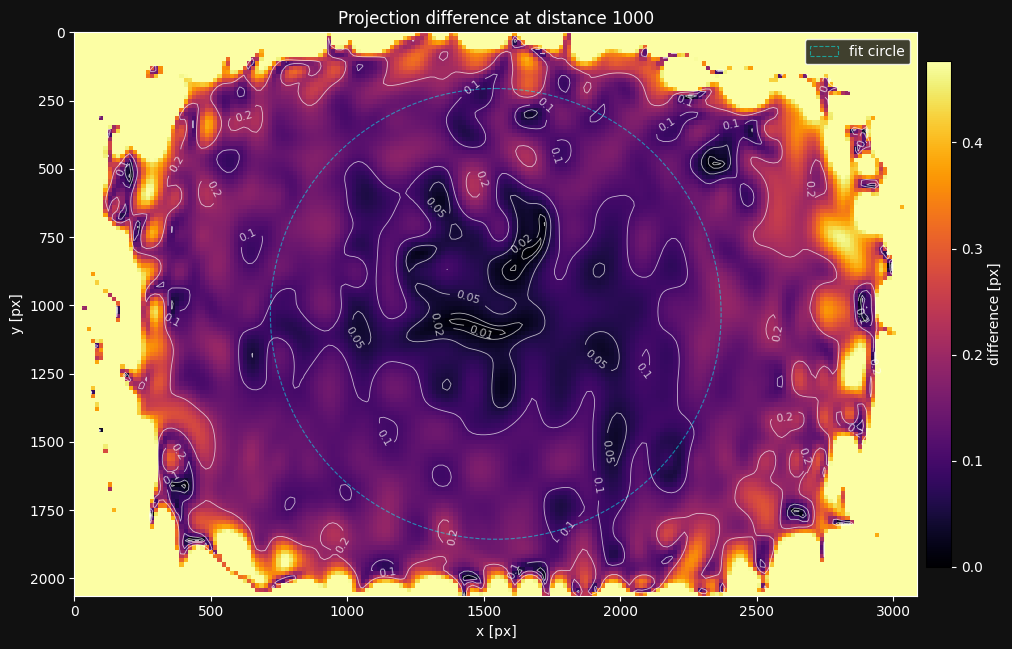

In [10]:
for x_knots in [15, 20, 30, 40]:
    y_knots = int(x_knots * 2/3)

    config = lb.PinholeSplinedConfig(
        image_height=image_height,
        image_width=image_width,
        num_knots_x=x_knots,
        num_knots_y=y_knots,
    )

    result_a = lb.calibrate_camera(
        target_points, 
        frames_a, 
        camera_model_config=config
    )
    result_b = lb.calibrate_camera(
        target_points, 
        frames_b, 
        camera_model_config=config
    )

    spline_model_a = result_a.camera_model
    spline_model_b = result_b.camera_model

    print(f"Result for {x_knots} x {y_knots} grid")

    print(f"Model A sigma: {result_a.residual_sigma_map():.3f} px")
    print(f"Model B sigma: {result_b.residual_sigma_map():.3f} px")

    lba.plot_projection_diff(spline_model_a, spline_model_b, distance=1000)


Interesting! the spine models seem to have higher variance, they differ way more than the opencv models. 
In contrast to the opencv models, it's possible that the reason is that the spline models have way more flexibility in how they overfit and underfit, resulting in higher variance.
We would likely need a larger dataset to reduce the variance.

We can also fit an opencv model and a spline model on all the data and see the difference:

In [11]:
opencv_config = lb.OpenCVConfig(
    image_height=image_height,
    image_width=image_width,
    initial_focal_length=1000,
    included_distortion_coefficients=lb.OpenCVConfig.FULL_14,
)

spline_config = lb.PinholeSplinedConfig(
    image_height=image_height,
    image_width=image_width,
    initial_focal_length=1000,
    num_knots_x=30,
    num_knots_y=20,
)

opencv_result = lb.calibrate_camera(
    target_points, 
    frames, 
    camera_model_config=opencv_config
)
spline_result = lb.calibrate_camera(
    target_points, 
    frames, 
    camera_model_config=spline_config
)

opencv_model = opencv_result.camera_model
spline_model = spline_result.camera_model

Computing initial poses with PnP...
PnP solved 101/101 frames
OpenCV pass 1: 0.5s (mean reproj=0.151px, worst=4.969px)
Outlier filtering: 90/10424 (0.9%) — re-optimizing...
OpenCV pass 2: 0.3s (mean reproj=0.140px, worst=0.609px)
Outlier filtering: 116/10424 (1.1%) — re-optimizing...
OpenCV pass 3: 0.1s (mean reproj=0.138px, worst=0.543px)
Target warp max deflection: 0.4683 (target units)
Fitted OpenCV seed model: 0.2s (FOV: 139.8° x 122.3°)
Spline FOV estimate: 0.4s (143.6° x 127.8°)
PnP solved 101/101 frames
Spline pass 1: 1.8s (mean reproj=0.128px, worst=4.967px)
Outlier filtering: 119/10424 (1.1%) — re-optimizing...
Spline pass 2: 1.3s (mean reproj=0.114px, worst=0.574px)
Outlier filtering: 158/10424 (1.5%) — re-optimizing...
Spline pass 3: 0.7s (mean reproj=0.112px, worst=0.615px)
Target warp max deflection: 0.4766 (target units)


Implied rotation: x=0.1621 y=0.0668 z=-0.0332 deg
Implied translation: [ 1.26267713e-06 -2.70286518e-06  3.08215507e-07]


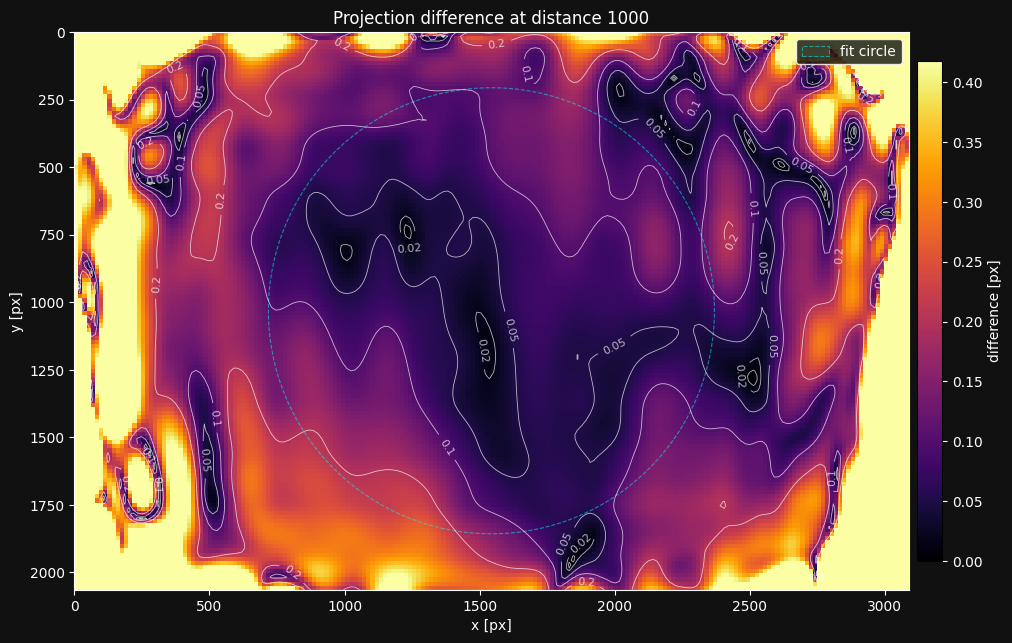

In [12]:
lba.plot_projection_diff(opencv_model, spline_model, distance=1000)

So there you have it, this is how you compare different camera models using `lensboy`.